This notebook explores the OECD datasets that will be used as training data for the models: CPI index, RGDP growth, unemployment rate. The data will be pre-processed by putting it into pandas dataframes with a shape of (countries, timesteps)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cpi_index = pd.read_csv('..\\data\\raw_data\\CPI_index.csv')
rgdp = pd.read_csv('..\\data\\raw_data\\RGDP_growth_rate.csv')
unemp = pd.read_csv('..\\data\\raw_data\\unemployment_rate.csv')

In [3]:
cpi_index.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA',
       'Reference area', 'FREQ', 'Frequency of observation', 'METHODOLOGY',
       'Methodology', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure',
       'EXPENDITURE', 'Expenditure', 'ADJUSTMENT', 'Adjustment',
       'TRANSFORMATION', 'Transformation', 'TIME_PERIOD', 'Time period',
       'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status',
       'UNIT_MULT', 'Unit multiplier', 'BASE_PER', 'Base period', 'DURABILITY',
       'Durability', 'DECIMALS', 'Decimals'],
      dtype='str')

All the columns in the original dataframe are not needed, as OECD includes lots of additional data for every sample, which is predominantly not required. Only the country, time stamp, and the value itself are needed

In [4]:
cpi_index = cpi_index[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
rgdp = rgdp[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
unemp = unemp[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
cpi_index.head()

,Reference area,TIME_PERIOD,OBS_VALUE
0,United States,2026-Q2,140.931500
1,Indonesia,2026-Q2,137.166300
2,United Kingdom,2026-Q2,142.100000
3,South Africa,1980-Q1,4.698460
4,South Africa,1980-Q2,4.852004


Due to unconsistent availability of data, for training and in-sample evaluation, only the values from 1993 to 2019 (incl) will be used for the following countries: Australia, Austria, Belgium, Canada, Denmark, Finland, France, Germany, Ireland, Italy,
Japan, Korea, Luxembourg, Mexico, Netherlands, New Zealand, Norway, Portugal, Spain, Sweden, United Kingdom, United States

In [5]:
cpi_index = cpi_index.loc[(cpi_index['TIME_PERIOD'].str[:4].astype(int) > 1992) & (cpi_index['TIME_PERIOD'].str[:4].astype(int) < 2020), :]
rgdp = rgdp.loc[(rgdp['TIME_PERIOD'].str[:4].astype(int) > 1992) & (rgdp['TIME_PERIOD'].str[:4].astype(int) < 2020), :]
unemp = unemp.loc[(unemp['TIME_PERIOD'].str[:4].astype(int) > 1992) & (unemp['TIME_PERIOD'].str[:4].astype(int) < 2020), :]

In [6]:
list_of_countries = ['Australia', 'Austria', 'Belgium', 'Canada', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland',
                     'Italy', 'Japan', 'Korea', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'Portugal',
                     'Spain', 'Sweden', 'United Kingdom', 'United States']
cpi_index = cpi_index.loc[cpi_index['Reference area'].isin(list_of_countries), :]
rgdp = rgdp.loc[rgdp['Reference area'].isin(list_of_countries), :]
unemp = unemp.loc[unemp['Reference area'].isin(list_of_countries), :]

In [7]:
# sorting the values
cpi_index = cpi_index.sort_values(by = 'TIME_PERIOD')
rgdp = rgdp.sort_values(by = 'TIME_PERIOD')
unemp = unemp.sort_values(by = 'TIME_PERIOD')
cpi_index.loc[cpi_index['Reference area'] == 'Australia']

,Reference area,TIME_PERIOD,OBS_VALUE
2281,Australia,1993-Q1,56.28047
2282,Australia,1993-Q2,56.46622
2283,Australia,1993-Q3,56.74483
2284,Australia,1993-Q4,56.83771
2285,Australia,1994-Q1,57.11632
...,...,...,...
2384,Australia,2018-Q4,105.96700
2385,Australia,2019-Q1,105.96700
2386,Australia,2019-Q2,106.61710
2387,Australia,2019-Q3,107.17440


RGDP is already in the form of percentage difference, unemployment is a percentage, but CPI is just a raw index, therefore I will compute the percentage growth for it 

In [8]:
for index, country in enumerate(list_of_countries):
    if index == 0:
        curr_series = cpi_index.loc[cpi_index['Reference area'] == country]
        curr_series['OBS_VALUE'] = curr_series['OBS_VALUE'].pct_change(periods = 4) * 100
        cpi_yoy = curr_series
    else:
        curr_series = cpi_index.loc[cpi_index['Reference area'] == country]
        curr_series['OBS_VALUE'] = curr_series['OBS_VALUE'].pct_change(periods = 4) * 100
        cpi_yoy = pd.concat([cpi_yoy, curr_series])
cpi_yoy

,Reference area,TIME_PERIOD,OBS_VALUE
2281,Australia,1993-Q1,NaN
2282,Australia,1993-Q2,NaN
2283,Australia,1993-Q3,NaN
2284,Australia,1993-Q4,NaN
2285,Australia,1994-Q1,1.485151
...,...,...,...
2016,United States,2018-Q4,2.203150
2017,United States,2019-Q1,1.644898
2018,United States,2019-Q2,1.811376
2019,United States,2019-Q3,1.757537


The data points for the first year cannot be computed for CPI, so only the data after 1994 (incl.) will be used

In [9]:
cpi_yoy = cpi_yoy[~cpi_yoy['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = 'TIME_PERIOD')
rgdp = rgdp[~rgdp['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = 'TIME_PERIOD')
unemp = unemp[~unemp['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = 'TIME_PERIOD')
# resetting the index 
cpi_yoy.reset_index(drop = True)
rgdp.reset_index(drop = True)
unemp.reset_index(drop = True)

,Reference area,TIME_PERIOD,OBS_VALUE
0,Mexico,1994-Q1,3.600000
1,Australia,1994-Q1,10.440280
2,Japan,1994-Q1,2.866667
3,Finland,1994-Q1,17.000000
4,United Kingdom,1994-Q1,9.900000
...,...,...,...
2283,Spain,2019-Q4,13.900000
2284,Germany,2019-Q4,3.000000
2285,Korea,2019-Q4,3.566667
2286,United Kingdom,2019-Q4,3.700000


In [10]:
# checking whether any data points are missing from currently selected data
print(cpi_yoy['OBS_VALUE'].isna().sum())
print(rgdp['OBS_VALUE'].isna().sum())
print(unemp['OBS_VALUE'].isna().sum())

0
0
0


I will now examine the time series plots of the metrics for several countries

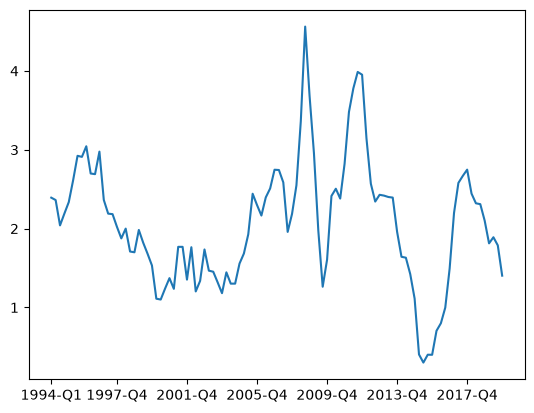

In [11]:
plt.plot(cpi_yoy.loc[cpi_yoy['Reference area'] == 'United Kingdom', 'TIME_PERIOD'], \
         cpi_yoy.loc[cpi_yoy['Reference area'] == 'United Kingdom', 'OBS_VALUE'], label = 'CPI inflation')
plt.xticks(cpi_yoy["TIME_PERIOD"][::350])
plt.show()

The CPI inflation in the UK saw a relatively stable outlook before the 2008 financial crisis, when it first rose to the highest in the given time period, then dipped, and continued to exhibit a much more volatile behaviour 

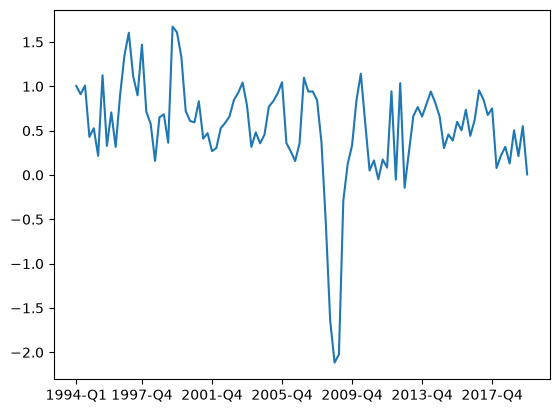

In [12]:
plt.plot(rgdp.loc[rgdp['Reference area'] == 'United Kingdom', 'TIME_PERIOD'], \
         rgdp.loc[rgdp['Reference area'] == 'United Kingdom', 'OBS_VALUE'], label = 'RGDP Growth')
plt.xticks(cpi_yoy["TIME_PERIOD"][::350])
plt.show()

RGDP growth in France was mostly moderately positive up to 2008, dipping into negatives two times in the early 2000s, and then saw a fall by 2% in 2009 Q1, exhibiting a a more volatile outlook after that, but still averaging at around 0.25%

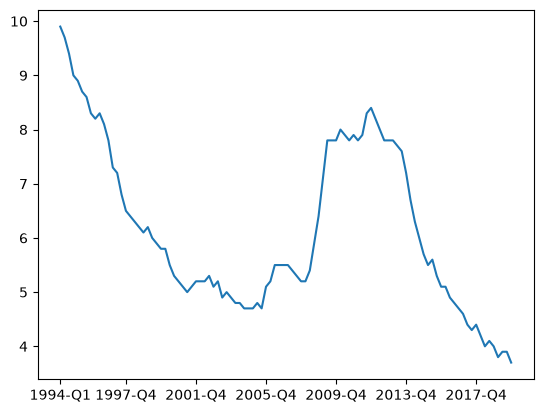

In [13]:
plt.plot(unemp.loc[unemp['Reference area'] == 'United Kingdom', 'TIME_PERIOD'], \
         unemp.loc[unemp['Reference area'] == 'United Kingdom', 'OBS_VALUE'], label = 'Unemployment rate')
plt.xticks(cpi_yoy["TIME_PERIOD"][::350])
plt.show()

In Germany, the unemployment rate peaked in 2005 at over 10%, but then saw a stable decrease, which was not significantly influenced by the financial crisis due to labour market reforms and the Kurzarbeit scheme

In [14]:
# saving the processed dataframes
cpi_yoy.to_csv('..\\data\\structured_data\\CPI_growth_yoy_dataframe.csv')
rgdp.to_csv('..\\data\\structured_data\\RGDP_growth_dataframe.csv')
unemp.to_csv('..\\data\\structured_data\\unemployment_rate_dataframe.csv')